#### Problem Statement:
- An online retail store is trying to understand the various customer purchase patterns for their firm, you are required to give enough evidence based insights to provide the same.

    - 	Find useful insights about the customer purchasing history that can be an added advantage for the online retailer.

    - 	Segment the customers based on their purchasing behavior.


In [26]:
#importing basic libraries needed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [2]:
# Loading dataset
df = pd.read_csv("OnlineRetail.csv")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850.0,United Kingdom


In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

##### Since the aim is to identify the customers shopping behaviour and segment them. The missing customerID data is of no use.
##### Dropping null values.

In [5]:
df.dropna(inplace=True)

In [6]:
# Checking Duplicates
df.duplicated().sum()

5225

In [7]:
# dropping duplicates
df.drop_duplicates(inplace=True)

In [8]:
# Checking data 
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    401604 non-null  object 
 1   StockCode    401604 non-null  object 
 2   Description  401604 non-null  object 
 3   Quantity     401604 non-null  int64  
 4   InvoiceDate  401604 non-null  object 
 5   UnitPrice    401604 non-null  float64
 6   CustomerID   401604 non-null  float64
 7   Country      401604 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.6+ MB


In [9]:
df['InvoiceDate'].nunique()

20460

In [10]:
# Dataset contains both "DD-MM-YYYY" and "DD/MM/YYYY" format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  object        
 1   StockCode    401604 non-null  object        
 2   Description  401604 non-null  object        
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[ns]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      401604 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.6+ MB


In [12]:
# Creating a total column to find out the total amount spent on each product at every bill.
df['Total'] = df['Quantity'] * df['UnitPrice']

In [13]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Total
count,401604.000000,401604,401604.000000,401604.000000,401604.000000
mean,12.183273,2011-07-10 12:08:23.848567552,3.474064,15281.160818,20.613638
min,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000,-168469.600000
25%,2.000000,2011-04-06 15:02:00,1.250000,13939.000000,4.250000
50%,5.000000,2011-07-29 15:40:00,1.950000,15145.000000,11.700000
75%,12.000000,2011-10-20 11:58:30,3.750000,16784.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,168469.600000
std,250.283037,NaN,69.764035,1714.006089,430.352218


<Axes: ylabel='Total'>

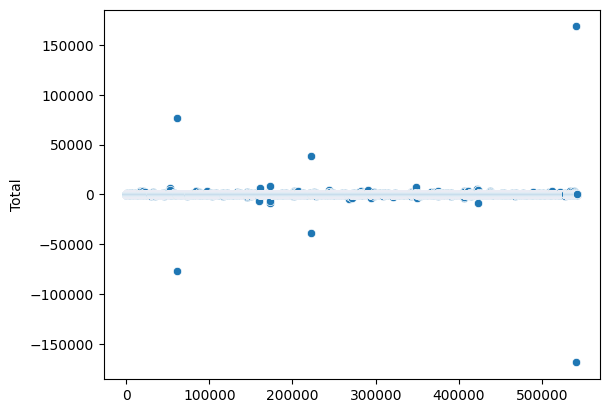

In [14]:
sns.scatterplot(df['Total'])

In [34]:
# Grouping to find out the total amount spent by each customer
Customer_total = df.groupby(df['CustomerID']).agg({'Total':'sum', 'InvoiceDate':'nunique', 'Quantity':'sum'})

In [35]:
Customer_total

,Total,InvoiceDate,Quantity
CustomerID,,,
12346.0,0.00,2,0
12347.0,4310.00,7,2458
12348.0,1797.24,4,2341
12349.0,1757.55,1,631
12350.0,334.40,1,197
...,...,...,...
18280.0,180.60,1,45
18281.0,80.82,1,54
18282.0,176.60,3,98


#### RFM Analysis
##### - Recency, Frequency and Monetary value anaysis gives customers behaiour todays their purchase history. Based on this customers can be segmented for how frequently they make a purchase, how much they spend and how recently they have purchased something. This helps in making decisions for each category of customers on how to retain and attract them.

In [27]:
# Finding the last date of purchase in dataset
Last_Date_of_Visit = df['InvoiceDate'].max() + dt.timedelta(days = 1)
# Making rfm matrix by grouping customers for their recency, frequency and Total amount spent by them
rfm = df.groupby('CustomerID').agg({'InvoiceDate' : lambda x: (Last_Date_of_Visit - x.max()).days, 'InvoiceNo':'count', 'Total':'sum'}).reset_index()
rfm.rename(columns = { 'InvoiceDate' : 'Recency', 'InvoiceNo' : 'Frequency', 'Total' : 'MonetaryValue'}, inplace = True)

In [29]:
#Recency score based on quantiles
#Assigning labels from 1-5,  1 being the lowest recency
rfm["Recency_score"] = pd.qcut(rfm['Recency'], 5, labels = [5, 4, 3, 2, 1])

#Frequency score
rfm["Frequency_score"] = pd.qcut(rfm['Frequency'].rank(method = "first"), 5, labels = [1, 2, 3, 4, 5])

In [30]:
#Combine Recency and Frequency scores to create RFM Segment
rfm["rfm_segment"] = rfm['Recency_score'].astype(str) + rfm['Frequency_score'].astype(str)

In [31]:
rfm

,CustomerID,Recency,Frequency,MonetaryValue,Recency_score,Frequency_score,rfm_segment
0,12346.0,326,2,0.00,1,1,11
1,12347.0,2,182,4310.00,5,5,55
2,12348.0,75,31,1797.24,2,3,23
3,12349.0,19,73,1757.55,4,4,44
4,12350.0,310,17,334.40,1,2,12
...,...,...,...,...,...,...,...
4367,18280.0,278,10,180.60,1,1,11
4368,18281.0,181,7,80.82,1,1,11
4369,18282.0,8,13,176.60,5,1,51
4370,18283.0,4,721,2045.53,5,5,55


#### Visualizing RFM Matrix

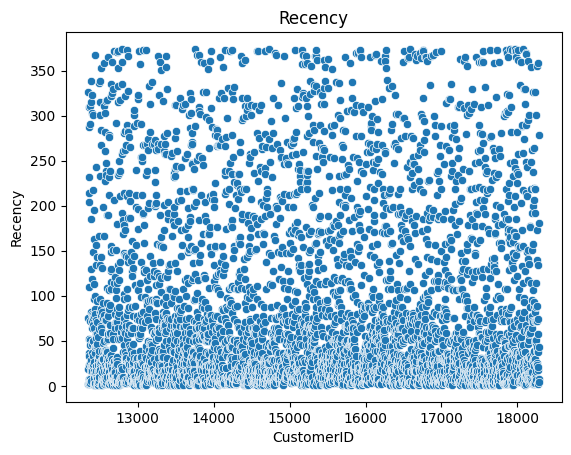

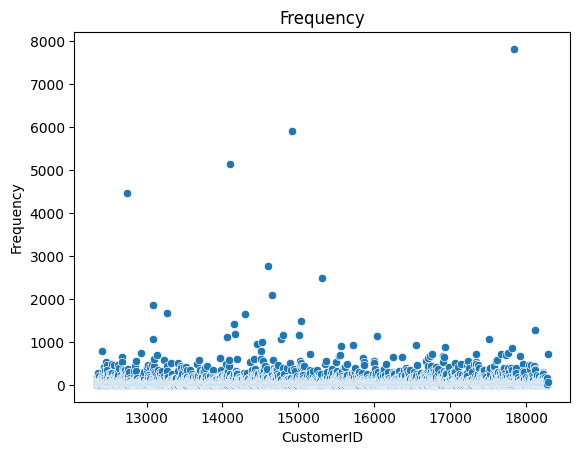

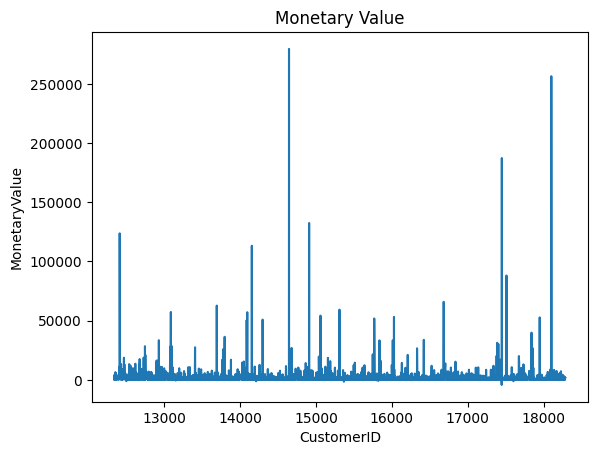

In [46]:
#recency
sns.scatterplot(data = rfm, y = 'Recency', x = 'CustomerID')
plt.title('Recency')
plt.show()
# Frequency Distribution
sns.scatterplot(data = rfm, y = 'Frequency', x = 'CustomerID')
plt.title('Frequency')
plt.show()
# Monetary Distribution
sns.lineplot(data = rfm, y = 'MonetaryValue', x = 'CustomerID')
plt.title('Monetary Value')
plt.show()

### Customer Segmentation
- Using K-means clustering for customer segmentaion based on rfm matrix
- using elbow method to find the number of clusters to form.

In [48]:
# Standardizing data

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
rfm_scaled = sc.fit_transform(rfm[['Recency','Frequency','MonetaryValue']])
rfm_scaled

array([[ 2.32202285, -0.39205597, -0.23041952],
       [-0.89373323,  0.39329343,  0.29405454],
       [-0.1691956 , -0.26552745, -0.01171748],
       ...,
       [-0.83418219, -0.34406239, -0.20892947],
       [-0.87388289,  2.74497857,  0.01849636],
       [-0.48680114, -0.09536842, -0.00684511]])

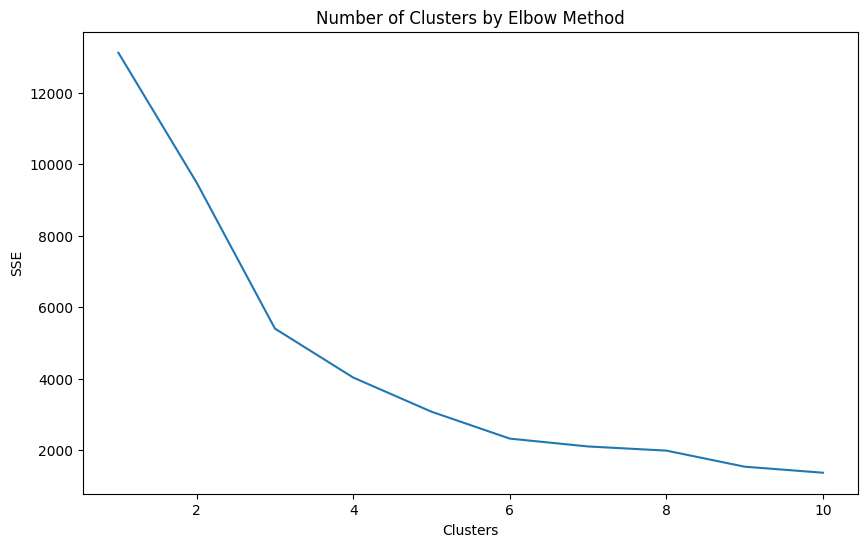

In [66]:
# Making elbow method plot to figure out optimum number of clusters
from sklearn.cluster import KMeans
sse = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k, random_state=1)
    kmeans.fit(rfm_scaled)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(10,6))
plt.plot(range(1,11),sse)
plt.title('Number of Clusters by Elbow Method')
plt.xlabel('Clusters')
plt.ylabel('SSE')
plt.show()

#### It shows the optimum nuber of clusters would be 3 or 6, choosing 6 for the segmentaion

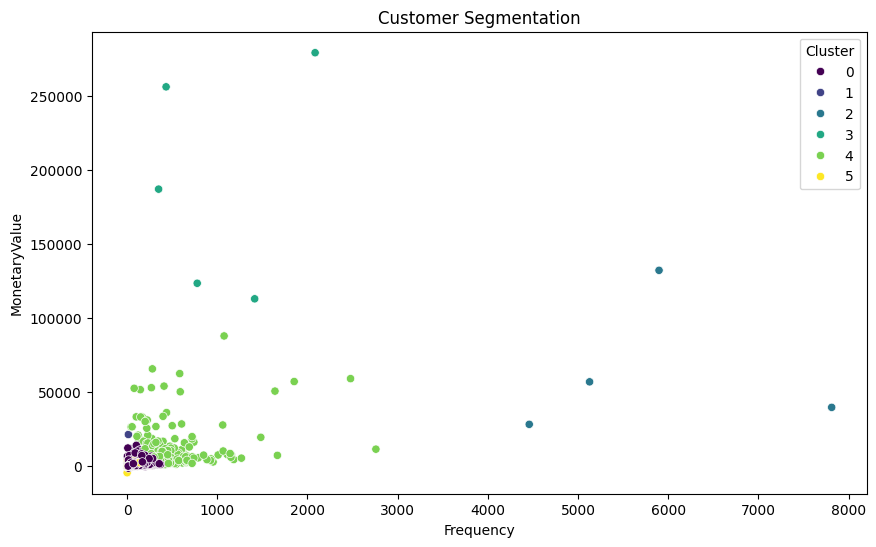

In [68]:
# Apply K-Means with the optimal number of clusters (e.g., 4 clusters)
kmeans = KMeans(n_clusters = 6, random_state = 42)
kmeans.fit(rfm_scaled)
rfm['Cluster'] = kmeans.labels_

# Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Frequency', y='MonetaryValue', hue='Cluster', palette='viridis')
plt.title('Customer Segmentation')
plt.show()

In [70]:
# Group by cluster to see the average characteristics of each cluster
cluster_summary = rfm.groupby('Cluster').agg({
    'MonetaryValue': 'mean',
    'Frequency': 'mean',
    'Recency': 'mean',
})

# Display the cluster summary
cluster_summary

,MonetaryValue,Frequency,Recency
Cluster,,,
0,1373.929037,79.527819,32.901706
1,403.506372,23.037855,295.372240
2,64463.562500,5824.250000,2.000000
3,192037.944000,1012.200000,9.000000
4,11417.962679,507.669643,12.093750
5,671.095292,37.719407,152.903585


## Conclusion - 
### The customers are segmented into 6 groups as per the above chart we can categories them as 
- 0 and 1 are Not regular or High spenders
- 2 and 4 are loyal and regular and happy customers
- 3 are Big spenders 
- 5 are just visting ones or unhappy ones